In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load data from Google Drive


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Change this path
base_path = "/content/drive/MyDrive/DSPLC_GCW"

train_raw = pd.read_csv(f"{base_path}/Hotel-A-train.csv")
valid_raw = pd.read_csv(f"{base_path}/Hotel-A-validation.csv")
test_raw = pd.read_csv(f"{base_path}/Hotel-A-test.csv")

print("Train shape:", train_raw.shape)
print("Validation shape:", valid_raw.shape)
print("Test shape:", test_raw.shape)

Train shape: (27499, 24)
Validation shape: (2749, 24)
Test shape: (4318, 23)


In [ ]:
# Clean data and create engineered variables

def clean_and_engineer(df, has_target=True):
    df = df.copy()

    # Parse date columns
    for col in ["Expected_checkin", "Expected_checkout", "Booking_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Standardise inconsistent labels
    if "Reservation_Status" in df.columns:
        df["Reservation_Status"] = df["Reservation_Status"].replace({
            "Check-out": "Check-Out",
            "Check-In": "Check-Out"   # validation data uses Check-In for completed stays
        })

    if "Ethnicity" in df.columns:
        df["Ethnicity"] = df["Ethnicity"].replace({
            "caucasian": "Caucasian"
        })

    # Derived fields
    df["lead_time"] = (df["Expected_checkin"] - df["Booking_date"]).dt.days
    df["stay_nights"] = (df["Expected_checkout"] - df["Expected_checkin"]).dt.days
    df["family_size"] = df["Adults"] + df["Children"] + df["Babies"]
    df["net_room_rate"] = df["Room_Rate"] * (1 - df["Discount_Rate"] / 100)
    df["potential_revenue"] = df["stay_nights"] * df["net_room_rate"]
    df["checkin_month"] = df["Expected_checkin"].dt.month

    # Age bands for reporting
    df["age_band"] = pd.cut(
        df["Age"],
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"],
        include_lowest=True
    )

    # Replacing invalid date logic with missing values
    df.loc[df["lead_time"] < 0, "lead_time"] = np.nan
    df.loc[df["stay_nights"] <= 0, "stay_nights"] = np.nan

    # Binary target
    if has_target and "Reservation_Status" in df.columns:
        df["failed_booking"] = df["Reservation_Status"].isin(["Canceled", "No-Show"]).astype(int)

    return df

train = clean_and_engineer(train_raw, has_target=True)
valid = clean_and_engineer(valid_raw, has_target=True)
test = clean_and_engineer(test_raw, has_target=False)

# Removing duplicate booking IDs from training data
train = train.drop_duplicates(subset="Reservation-id", keep="first").copy()

print("Cleaned train:", train.shape)
print("Cleaned validation:", valid.shape)
print("Cleaned test:", test.shape)

Cleaned train: (27495, 32)
Cleaned validation: (2749, 32)
Cleaned test: (4318, 30)


In [ ]:
# Key EDA summary tables

def failed_rate_table(df, group_col):
    temp = df.groupby(group_col, observed=False).agg(
        bookings=("failed_booking", "size"),
        failed_rate=("failed_booking", "mean"),
        cancellation_rate=("Reservation_Status", lambda s: (s == "Canceled").mean()),
        no_show_rate=("Reservation_Status", lambda s: (s == "No-Show").mean())
    ).reset_index()

    for col in ["failed_rate", "cancellation_rate", "no_show_rate"]:
        temp[col] = (temp[col] * 100).round(2)

    return temp.sort_values("failed_rate", ascending=False)

# Lead-time bands
train["lead_time_band"] = pd.cut(
    train["lead_time"],
    bins=[-0.1, 7, 30, 90, 180, 365, 10000],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "366+"]
)

print("Lead time")
display(failed_rate_table(train.dropna(subset=["lead_time"]), "lead_time_band"))

print("Hotel type")
display(failed_rate_table(train, "Hotel_Type"))

print("Deposit type")
display(failed_rate_table(train, "Deposit_type"))

print("Repeat-customer behaviour")
display(failed_rate_table(train, "Visted_Previously"))

print("Booking channel")
display(failed_rate_table(train, "Booking_channel"))

print("Seasonality by check-in month")
display(failed_rate_table(train, "checkin_month").sort_values("checkin_month"))

print("Meal type")
display(failed_rate_table(train, "Meal_Type"))

Lead time


,lead_time_band,bookings,failed_rate,cancellation_rate,no_show_rate
3,91-180,9676,26.83,17.71,9.12
2,31-90,7705,21.62,14.38,7.24
4,181-365,5085,21.55,14.14,7.41
1,8-30,3146,20.12,13.29,6.83
0,0-7,1160,19.31,12.84,6.47
5,366+,217,0.00,0.00,0.00


Hotel type


,Hotel_Type,bookings,failed_rate,cancellation_rate,no_show_rate
2,Resort,9105,23.53,15.84,7.69
1,City Hotel,9134,22.74,14.91,7.83
0,Airport Hotels,9256,22.03,14.37,7.66


Deposit type


...

,Booking_channel,bookings,failed_rate,cancellation_rate,no_show_rate
1,Direct,7940,22.92,15.00,7.92
2,Online,15573,22.74,15.03,7.72
0,Agent,3982,22.50,15.14,7.36


Seasonality by check-in month


,checkin_month,bookings,failed_rate,cancellation_rate,no_show_rate
0,1,2371,21.13,13.75,7.38
1,2,2237,23.69,15.87,7.82
2,3,2580,24.92,17.29,7.64
3,4,2395,23.51,15.87,7.64
4,5,2255,23.24,15.39,7.85
5,6,2138,22.83,15.06,7.76
6,7,3002,24.02,15.66,8.36
7,8,2978,29.05,19.24,9.81
8,9,1839,16.91,10.66,6.25
9,10,2250,15.96,10.40,5.56


Meal type


,Meal_Type,bookings,failed_rate,cancellation_rate,no_show_rate
1,FB,5194,38.56,25.49,13.07
2,HB,8078,25.63,16.55,9.07
0,BB,14223,15.36,10.36,5.01


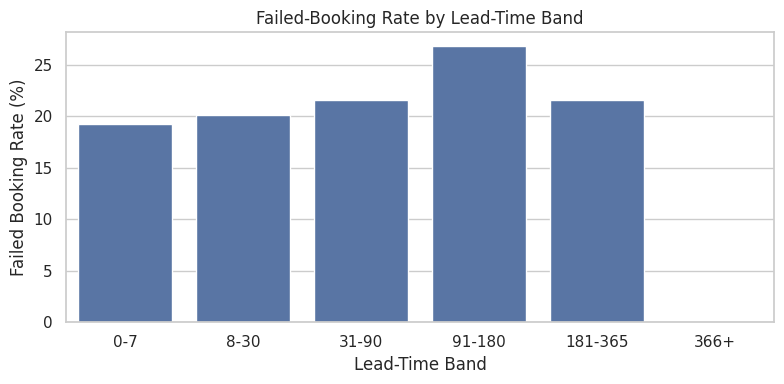

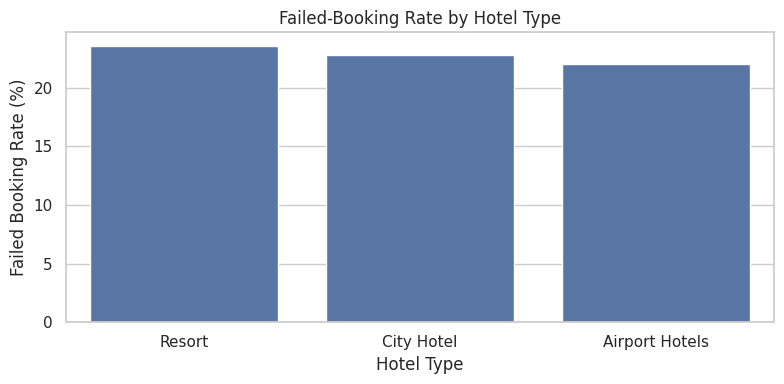

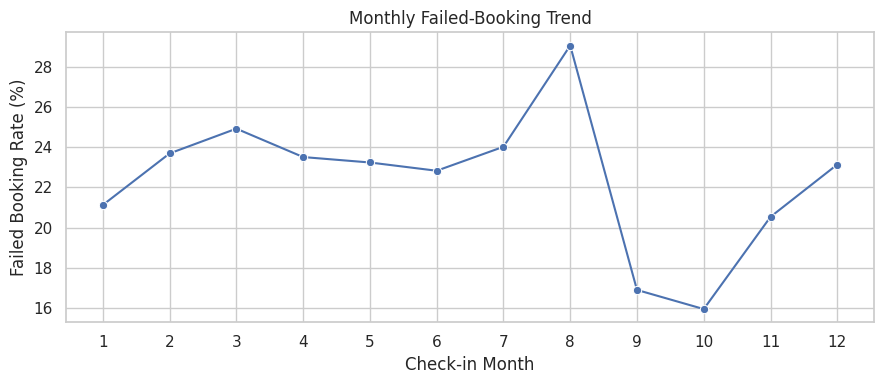

In [ ]:
# Charts

lead_plot = failed_rate_table(train.dropna(subset=["lead_time"]), "lead_time_band")
hotel_plot = failed_rate_table(train, "Hotel_Type")
month_plot = failed_rate_table(train, "checkin_month").sort_values("checkin_month")

plt.figure(figsize=(8, 4))
sns.barplot(data=lead_plot, x="lead_time_band", y="failed_rate")
plt.title("Failed-Booking Rate by Lead-Time Band")
plt.xlabel("Lead-Time Band")
plt.ylabel("Failed Booking Rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=hotel_plot, x="Hotel_Type", y="failed_rate")
plt.title("Failed-Booking Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Failed Booking Rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
sns.lineplot(data=month_plot, x="checkin_month", y="failed_rate", marker="o")
plt.title("Monthly Failed-Booking Trend")
plt.xlabel("Check-in Month")
plt.ylabel("Failed Booking Rate (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

,Metric,Value,Share_of_Total_%
0,Cancellation loss,1160410.45,15.02
1,No-show loss,594017.75,7.69
2,Combined failed-booking loss,1754428.20,22.71
3,Total potential revenue,7724462.80,100.00


Loss by age


,age_band,Revenue_Loss
1,26-35,347017.70
4,56-65,334400.70
2,36-45,332602.20
3,46-55,324097.45
0,<=25,256960.30
5,65+,159349.85


Loss by region


,Country_region,Revenue_Loss
2,South,692184.95
1,North,368177.75
0,East,349926.15
3,West,344139.35


Loss by hotel type


,Hotel_Type,Revenue_Loss
2,Resort,596404.05
1,City Hotel,581986.45
0,Airport Hotels,576037.70


Top 10 highest-loss customer segments


,Hotel_Type,Booking_channel,Country_region,Failed_Bookings,Revenue_Loss
22,City Hotel,Online,South,477,135391.50
34,Resort,Online,South,478,131697.25
10,Airport Hotels,Online,South,475,131451.00
33,Resort,Online,North,271,74759.70
6,Airport Hotels,Direct,South,243,68299.90
23,City Hotel,Online,West,236,67913.60
30,Resort,Direct,South,242,66540.45
9,Airport Hotels,Online,North,234,66297.30
20,City Hotel,Online,East,232,66253.05
35,Resort,Online,West,240,65176.90


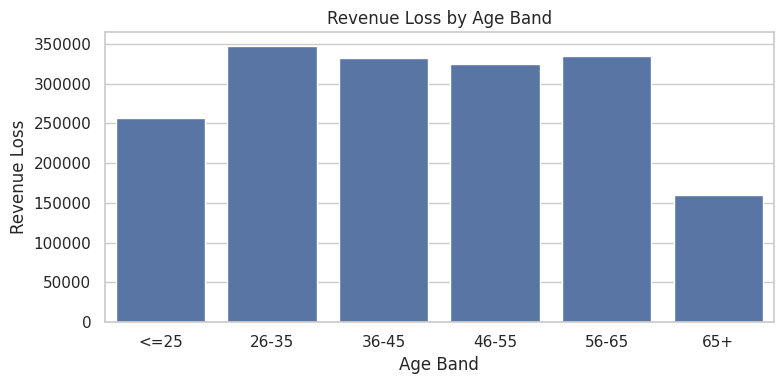

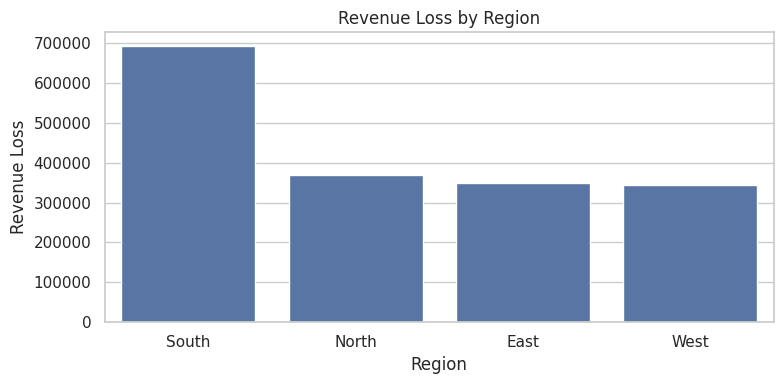

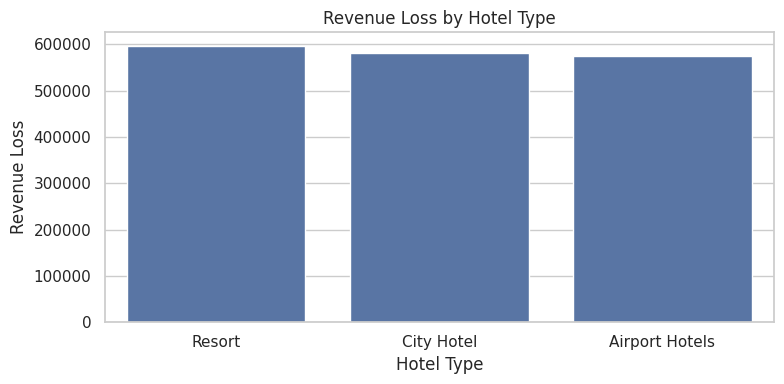

In [ ]:
# Revenue loss results

# Main revenue-loss figures
cancellation_loss = train.loc[train["Reservation_Status"] == "Canceled", "potential_revenue"].sum()
no_show_loss = train.loc[train["Reservation_Status"] == "No-Show", "potential_revenue"].sum()
failed_loss = train.loc[train["failed_booking"] == 1, "potential_revenue"].sum()
total_potential_revenue = train["potential_revenue"].sum()

revenue_summary = pd.DataFrame({
    "Metric": ["Cancellation loss", "No-show loss", "Combined failed-booking loss", "Total potential revenue"],
    "Value": [cancellation_loss, no_show_loss, failed_loss, total_potential_revenue]
})
revenue_summary["Share_of_Total_%"] = (revenue_summary["Value"] / total_potential_revenue * 100).round(2)

display(revenue_summary.round(2))

# Loss by age
loss_by_age = (
    train.loc[train["failed_booking"] == 1]
    .groupby("age_band", observed=False)["potential_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"potential_revenue": "Revenue_Loss"})
    .sort_values("Revenue_Loss", ascending=False)
)

# Loss by region
loss_by_region = (
    train.loc[train["failed_booking"] == 1]
    .groupby("Country_region")["potential_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"potential_revenue": "Revenue_Loss"})
    .sort_values("Revenue_Loss", ascending=False)
)

# Loss by hotel type
loss_by_hotel = (
    train.loc[train["failed_booking"] == 1]
    .groupby("Hotel_Type")["potential_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"potential_revenue": "Revenue_Loss"})
    .sort_values("Revenue_Loss", ascending=False)
)

# Highest-loss customer segments
top_segments = (
    train.loc[train["failed_booking"] == 1]
    .groupby(["Hotel_Type", "Booking_channel", "Country_region"])
    .agg(
        Failed_Bookings=("Reservation-id", "count"),
        Revenue_Loss=("potential_revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue_Loss", ascending=False)
    .head(10)
)

print("Loss by age")
display(loss_by_age.round(2))

print("Loss by region")
display(loss_by_region.round(2))

print("Loss by hotel type")
display(loss_by_hotel.round(2))

print("Top 10 highest-loss customer segments")
display(top_segments.round(2))

# Charts
plt.figure(figsize=(8, 4))
sns.barplot(data=loss_by_age, x="age_band", y="Revenue_Loss")
plt.title("Revenue Loss by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Revenue Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=loss_by_region, x="Country_region", y="Revenue_Loss")
plt.title("Revenue Loss by Region")
plt.xlabel("Region")
plt.ylabel("Revenue Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=loss_by_hotel, x="Hotel_Type", y="Revenue_Loss")
plt.title("Revenue Loss by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Revenue Loss")
plt.tight_layout()
plt.show()

# Important notes:
# The dataset does not contain a separate country column.
# So country-level revenue loss cannot be produced.

In [ ]:
# Cell 6: model comparison for Section 6.3

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

feature_cols = [
    "Gender", "Age", "Ethnicity", "Educational_Level", "Income", "Country_region",
    "Hotel_Type", "Adults", "Children", "Babies", "Meal_Type",
    "Visted_Previously", "Previous_Cancellations", "Deposit_type",
    "Booking_channel", "Required_Car_Parking", "Use_Promotion",
    "Discount_Rate", "Room_Rate", "lead_time", "stay_nights",
    "family_size", "checkin_month"
]

X_train = train[feature_cols]
y_train = train["failed_booking"]

X_valid = valid[feature_cols]
y_valid = valid["failed_booking"]

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [col for col in feature_cols if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
        C=0.1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        criterion="entropy",
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=10,
        max_features=0.5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}
conf_matrices = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_valid)
    y_prob = pipe.predict_proba(X_valid)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc_score(y_valid, y_prob)
    })

    fitted_models[model_name] = pipe
    conf_matrices[model_name] = confusion_matrix(y_valid, y_pred)

results_df = pd.DataFrame(results).round(4)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5038,0.4345,0.6550,0.5224,0.5183
1,Decision Tree,0.4536,0.4217,0.8578,0.5654,0.5192
2,Random Forest,0.4933,0.4304,0.6892,0.5299,0.5217


,Feature,Importance
0,Meal_Type,0.6336
1,lead_time,0.3030
2,checkin_month,0.0401
3,Room_Rate,0.0042
4,Age,0.0040
5,Deposit_type,0.0020
6,Hotel_Type,0.0016
7,family_size,0.0014
8,Country_region,0.0013
9,Income,0.0013


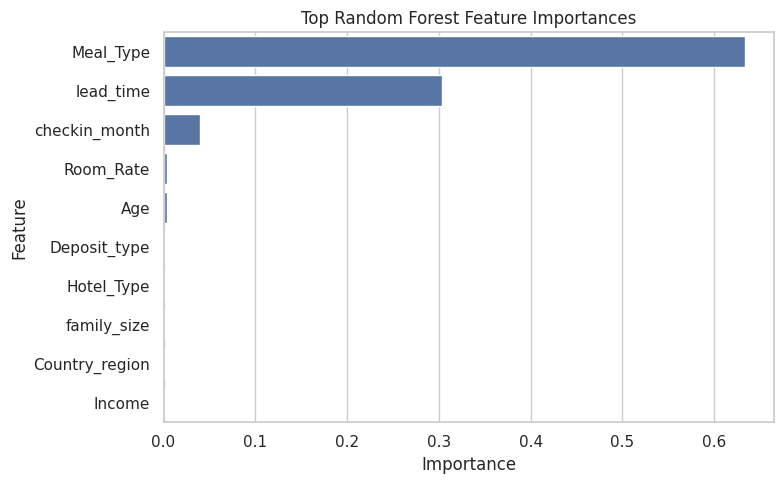

In [ ]:
# Random Forest feature importance for Section 6.4

rf_pipe = fitted_models["Random Forest"]

# Expanded feature names after one-hot encoding
ohe = rf_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Raw importances from Random Forest
rf_importances = rf_pipe.named_steps["model"].feature_importances_

# Aggregate one-hot encoded columns back to original feature names
aggregated_importance = {}

for feature_name, importance in zip(all_feature_names, rf_importances):
    if feature_name in numeric_features:
        key = feature_name
    else:
        key = None
        for original_col in categorical_features:
            if feature_name.startswith(original_col + "_"):
                key = original_col
                break
        if key is None:
            key = feature_name

    aggregated_importance[key] = aggregated_importance.get(key, 0) + importance

importance_df = (
    pd.DataFrame({
        "Feature": list(aggregated_importance.keys()),
        "Importance": list(aggregated_importance.values())
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(10).round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()